# 期現套利 HBT：跨日留倉 Runner

這個 Notebook 是可調參數的薄 runner；底層邏輯放在同資料夾與 `future_spot/arbitrage/` 的 Python 模組。預設執行 2026 年 1–7 月單次連續回測：未平倉部位會帶入下一交易日，不在隔日篩選名單的舊合約也會保留，到期日不得殘倉或自動換月。既有 event NPZ 會直接重用。

In [1]:
from pathlib import Path
import sys

CURRENT_DIR = Path.cwd().resolve()
TEST_ROOT = CURRENT_DIR if (CURRENT_DIR / 'backtest_config.py').exists() else CURRENT_DIR / 'future_spot' / 'test'
if not TEST_ROOT.exists():
    raise FileNotFoundError('Open this notebook from future_spot/test or the repository root')
PROJECT_ROOT = TEST_ROOT.parent
WORKSPACE_ROOT = PROJECT_ROOT.parent
for path in (TEST_ROOT, PROJECT_ROOT, WORKSPACE_ROOT, PROJECT_ROOT / 'scripts'):
    if str(path) not in sys.path:
        sys.path.insert(0, str(path))

from IPython.display import Image, display
from backtest_config import default_notebook_args
from backtest_pipeline import run_backtest_pipeline
from report_tables import build_report_tables
from report_plots import save_report_plots

## 1. 參數

In [2]:
# 這 8 個到期殘倉 run 會從 HBT、交易、績效與資金重播中刪除。
EXCLUDED_RUN_KEYS = {
    '2026-04-15::1802_KUFD6',
    '2026-05-20::6173_PKFE6',
    '2026-07-15::2340_FYFG6',
    '2026-07-15::2408_CYFG6',
    '2026-07-15::3714_QBFG6',
    '2026-07-15::4919_REFG6',
    '2026-07-15::5371_NMFG6',
    '2026-07-15::6257_MQFG6',
}

args = default_notebook_args(
    start_date='2026-01-01',
    end_date='2026-07-31',
    carry_positions=True,
    total_capital=50_000_000.0,
    futures_margin_rate=0.20,
    spot_equity_rate=0.40,
    leverage=False,             # False：期貨與現股皆按 100% 自有資金
    future_order_latency_ms=1.0,
    future_response_latency_ms=1.0,
    future_feed_latency_offset_ms=0.0,
    spot_order_latency_ms=1.0,
    spot_response_latency_ms=35.0,
    spot_feed_latency_offset_ms=0.0,
    low_memory_reports=True,    # 報表前釋放大型 frames，改由 CSV 分批彙總
    report_mode='summary',      # 不建立 failure windows / 逐筆 capital 明細
    report_chunk_rows=25_000,
    continue_on_error=True,     # 保留已知缺資料日；下方仍會獨立檢查到期日殘倉
    post_first_feed_wait='spot',
    post_first_feed_timeout_ms=5000.0,
    rebuild_hbt_results=False,  # manifest 失效時仍會自動重跑 HBT
    excluded_run_keys=sorted(EXCLUDED_RUN_KEYS),
)

# 這 7 天已由 runner 從日期序列排除；圖表沿用相同設定做防呆。
PLOT_EXCLUDED_DATES = tuple(args.excluded_dates)

args.output_dir

PosixPath('/home/zoufuc/hftbacktest/future_spot/output/hbt_daily_full_market_20260101_20260731_future_order_1ms_response_1ms_feed_0ms_spot_order_1ms_response_35ms_feed_0ms')

## 2. 執行完整回測與檢查跨日持倉

In [3]:
artifacts = run_backtest_pipeline(args)
display(artifacts.frame('summary').head(20))
display(artifacts.frame('entry_exit_index').head(20))

carry_status = artifacts.frame('position_carry_status')
display(carry_status.loc[carry_status['universe_source'].ne('selected')].head(30))
expiry_violations = carry_status.loc[carry_status['status'].eq('expiry_position_remaining')].copy()
if not expiry_violations.empty:
    display(expiry_violations)
    raise RuntimeError(f'期貨到期日仍有殘倉：{len(expiry_violations)} 筆')
for frame_name in ('summary', 'trades', 'position_carry_status'):
    frame = artifacts.frame(frame_name)
    leaked = frame.loc[frame['run_key'].astype(str).isin(EXCLUDED_RUN_KEYS)] if not frame.empty else frame
    if not leaked.empty:
        raise RuntimeError(f'{frame_name} 仍含已排除 run_key：{sorted(leaked.run_key.unique())}')
print('跨日留倉稽核通過：8 個排除 run_key 已從 HBT、交易與績效資料刪除。')

input_rows=1577
converted_rows=1577
skipped_symbol_rows=0
skipped_status_rows=0
skipped_time_rows=0
raw_events=19053
output_events=19053
depth_events=18842
trade_events=211
opening_jump_qty=0.0
first_exch_ts=1776992401236000000
last_exch_ts=1777008290936000000
min_feed_latency=0
max_feed_latency=0
qa_rows_checked=1000
best_bid_mismatches=0
best_ask_mismatches=0
trade_qty_mismatches=0
load_seconds=5.060424
event_build_seconds=0.131390
normalize_seconds=0.001257
write_seconds=0.015476
output=/home/zoufuc/hftbacktest/data/tw_stock_future_events/PKFE6_20260424_090000_132500.npz
input_rows=18507
converted_rows=18507
skipped_symbol_rows=0
skipped_status_rows=0
skipped_time_rows=0
raw_events=223790
output_events=223790
depth_events=222084
trade_events=1706
opening_jump_qty=0.0
first_exch_ts=1782349200616000000
last_exch_ts=1782365096500000000
min_feed_latency=0
max_feed_latency=0
qa_rows_checked=1000
best_bid_mismatches=0
best_ask_mismatches=0
trade_qty_mismatches=0
load_seconds=5.722120
even

,trade_date,run_key,pair_name,spot_symbol,future_symbol,rows,filled_pairs,second_leg_failures,flatten_count,realized_pnl,...,post_first_feed_poll_ns,spot_order_latency_ns,future_order_latency_ns,spot_response_latency_ns,future_response_latency_ns,spot_feed_latency_offset_ns,future_feed_latency_offset_ns,strategy_engine,scan_calls,python_decisions
0,2026-01-08,2026-01-08::1303_CAFA6,1303_CAFA6,1303,CAFA6,0,0,0,0,0.0,...,10000000,1000000,1000000,35000000,1000000,0,0,numba,265,264
1,2026-01-08,2026-01-08::2002_CBFA6,2002_CBFA6,2002,CBFA6,0,0,0,0,0.0,...,10000000,1000000,1000000,35000000,1000000,0,0,numba,265,264
2,2026-01-08,2026-01-08::1301_CFFA6,1301_CFFA6,1301,CFFA6,0,0,0,0,0.0,...,10000000,1000000,1000000,35000000,1000000,0,0,numba,265,264
3,2026-01-08,2026-01-08::2409_CHFA6,2409_CHFA6,2409,CHFA6,0,0,0,0,0.0,...,10000000,1000000,1000000,35000000,1000000,0,0,numba,265,264
4,2026-01-08,2026-01-08::1605_CSFA6,1605_CSFA6,1605,CSFA6,0,0,0,0,0.0,...,10000000,1000000,1000000,35000000,1000000,0,0,numba,265,264
5,2026-01-08,2026-01-08::2408_CYFA6,2408_CYFA6,2408,CYFA6,0,0,0,0,0.0,...,10000000,1000000,1000000,35000000,1000000,0,0,numba,265,264
6,2026-01-08,2026-01-08::2603_CZFA6,2603_CZFA6,2603,CZFA6,0,0,0,0,0.0,...,10000000,1000000,1000000,35000000,1000000,0,0,numba,265,264
7,2026-01-08,2026-01-08::2609_DAFA6,2609_DAFA6,2609,DAFA6,0,0,0,0,0.0,...,10000000,1000000,1000000,35000000,1000000,0,0,numba,265,264
8,2026-01-08,2026-01-08::1101_DFFA6,1101_DFFA6,1101,DFFA6,0,0,0,0,0.0,...,10000000,1000000,1000000,35000000,1000000,0,0,numba,265,264
9,2026-01-08,2026-01-08::1326_DGFA6,1326_DGFA6,1326,DGFA6,0,0,0,0,0.0,...,10000000,1000000,1000000,35000000,1000000,0,0,numba,265,264


,trade_date,run_key,pair_name,rows,entry_signal_rows,entry_execution_rows,exit_execution_rows
0,2026-01-08,2026-01-08::1303_CAFA6,1303_CAFA6,0,0,0,0
1,2026-01-08,2026-01-08::2002_CBFA6,2002_CBFA6,0,0,0,0
2,2026-01-08,2026-01-08::1301_CFFA6,1301_CFFA6,0,0,0,0
3,2026-01-08,2026-01-08::2409_CHFA6,2409_CHFA6,0,0,0,0
4,2026-01-08,2026-01-08::1605_CSFA6,1605_CSFA6,0,0,0,0
5,2026-01-08,2026-01-08::2408_CYFA6,2408_CYFA6,0,0,0,0
6,2026-01-08,2026-01-08::2603_CZFA6,2603_CZFA6,0,0,0,0
7,2026-01-08,2026-01-08::2609_DAFA6,2609_DAFA6,0,0,0,0
8,2026-01-08,2026-01-08::1101_DFFA6,1101_DFFA6,0,0,0,0
9,2026-01-08,2026-01-08::1326_DGFA6,1326_DGFA6,0,0,0,0


,trade_date,run_key,pair_name,spot_symbol,future_symbol,universe_source,carried_from_date,initial_quantity,initial_direction,final_quantity,final_direction,expiry_date,is_expiry_date,carry_to_next_date,status
68,2026-01-09,2026-01-09::6770_QZFA6,6770_QZFA6,6770,QZFA6,carried_position,2026-01-08,9,ENTER_LONG_SPOT_SHORT_FUTURE,10,ENTER_LONG_SPOT_SHORT_FUTURE,2026-01-21,False,True,carried_forward
94,2026-01-12,2026-01-12::6770_QZFA6,6770_QZFA6,6770,QZFA6,carried_position,2026-01-09,10,ENTER_LONG_SPOT_SHORT_FUTURE,10,ENTER_LONG_SPOT_SHORT_FUTURE,2026-01-21,False,True,carried_forward
116,2026-01-13,2026-01-13::6282_KFFA6,6282_KFFA6,6282,KFFA6,selected+carried,2026-01-12,8,ENTER_LONG_SPOT_SHORT_FUTURE,0,HOLD,2026-01-21,False,False,closed
130,2026-01-13,2026-01-13::6770_QZFA6,6770_QZFA6,6770,QZFA6,carried_position,2026-01-12,10,ENTER_LONG_SPOT_SHORT_FUTURE,10,ENTER_LONG_SPOT_SHORT_FUTURE,2026-01-21,False,True,carried_forward
170,2026-01-14,2026-01-14::6770_QZFA6,6770_QZFA6,6770,QZFA6,carried_position,2026-01-13,10,ENTER_LONG_SPOT_SHORT_FUTURE,10,ENTER_LONG_SPOT_SHORT_FUTURE,2026-01-21,False,True,carried_forward
202,2026-01-15,2026-01-15::6770_QZFA6,6770_QZFA6,6770,QZFA6,carried_position,2026-01-14,10,ENTER_LONG_SPOT_SHORT_FUTURE,10,ENTER_LONG_SPOT_SHORT_FUTURE,2026-01-21,False,True,carried_forward
237,2026-01-16,2026-01-16::6770_QZFA6,6770_QZFA6,6770,QZFA6,carried_position,2026-01-15,10,ENTER_LONG_SPOT_SHORT_FUTURE,10,ENTER_LONG_SPOT_SHORT_FUTURE,2026-01-21,False,True,carried_forward
238,2026-01-19,2026-01-19::1303_CAFA6,1303_CAFA6,1303,CAFA6,selected+carried,2026-01-16,10,ENTER_LONG_SPOT_SHORT_FUTURE,0,HOLD,2026-01-21,False,False,closed
273,2026-01-19,2026-01-19::6770_QZFA6,6770_QZFA6,6770,QZFA6,carried_position,2026-01-16,10,ENTER_LONG_SPOT_SHORT_FUTURE,10,ENTER_LONG_SPOT_SHORT_FUTURE,2026-01-21,False,True,carried_forward
298,2026-01-20,2026-01-20::1717_QOFA6,1717_QOFA6,1717,QOFA6,selected+carried,2026-01-19,4,ENTER_LONG_SPOT_SHORT_FUTURE,0,HOLD,2026-01-21,False,False,closed


跨日留倉稽核通過：8 個排除 run_key 已從 HBT、交易與績效資料刪除。


## 3. 產生資金與績效報表

預設使用低記憶體 summary 模式：先釋放大型 in-memory frames，再以 25,000 rows/batch 從既有 CSV 彙總；不會重跑 HBT。

In [4]:
reports = build_report_tables(artifacts)
display(reports.frame('symbol_profit').head(30))
display(reports.frame('failure_overview'))
display(reports.frame('capital_constraint_summary'))
display(reports.frame('daily_capital_constraint').tail(20))
print(f'Report CSV directory: {reports.output_dir}')

,spot_symbol,trade_days,pair_names,estimated_profit,avg_daily_profit,filled_pairs,second_leg_failures,flatten_count,final_quantity_abs
0,2492,22,6,3.476665e+06,158030.224818,284,25,10,24.0
1,2327,99,8,1.318862e+06,13321.841434,484,3,1,190.0
2,2454,14,4,9.857453e+05,70410.377857,106,1,1,50.0
3,6488,10,3,9.791449e+05,97914.492200,334,41,26,69.0
4,3189,78,8,6.426548e+05,8239.163692,524,10,1,121.0
5,4958,97,8,6.346100e+05,6542.370773,344,6,0,119.0
6,3037,79,8,5.290197e+05,6696.452025,396,3,0,119.0
7,6239,45,6,4.355472e+05,9678.827222,144,1,1,43.0
8,2408,105,8,3.918189e+05,3731.608343,774,8,0,176.0
9,2337,91,8,3.732156e+05,4101.270059,554,6,1,66.0


,pairs_with_summary_failures,failure_trade_rows,market_window_rows,trade_dates,pair_names,flatten_count
0,159,2082,0,65,96,1886.0


,total_capital,futures_margin_rate,spot_equity_rate,effective_futures_margin_rate,effective_spot_equity_rate,leverage,carry_positions,futures_capital_limit,spot_capital_limit,matched_notional_limit,...,accepted_exits,discarded_open_lots,ending_open_lot_days,capital_filtered_realized_pnl,capital_filtered_realized_roi,peak_spot_capital,peak_futures_capital,peak_total_capital,peak_capital_utilization,replay_scope
0,50000000.0,0.2,0.4,1.0,1.0,False,True,25000000.0,25000000.0,25000000.0,...,4179,6,2243,7.069581e+06,0.141392,2.479039e+07,24999800.0,4.977929e+07,0.995586,continuous_position_candidate_replay


,trade_date,accepted_entries,rejected_entries,accepted_exits,ignored_unmatched_exits,discarded_open_lots,ending_open_lots,realized_pnl,ending_spot_capital,ending_futures_capital,ending_total_capital,peak_spot_capital,peak_futures_capital,peak_total_capital,peak_capital_utilization
84,2026-06-08,21,0,41,0,0,10,2.287214e+04,9.783902e+05,986000.0,1.964390e+06,7.811115e+06,7886000.0,1.569712e+07,0.313942
85,2026-06-09,11,0,21,0,0,0,4.785285e+03,1.635635e-08,0.0,1.635635e-08,1.252400e+06,1264000.0,2.516400e+06,0.050328
86,2026-06-10,10,0,10,0,0,0,2.075993e+04,1.653098e-08,0.0,1.653098e-08,4.723884e+06,4800000.0,9.523884e+06,0.190478
87,2026-06-16,35,0,35,0,0,0,5.722584e+04,1.682201e-08,0.0,1.682201e-08,1.518606e+07,15370000.0,3.055606e+07,0.611121
88,2026-06-17,10,0,10,0,0,0,2.676403e+03,1.685112e-08,0.0,1.685112e-08,7.741087e+05,782000.0,1.556109e+06,0.031122
89,2026-06-18,30,0,0,0,0,30,0.000000e+00,1.014084e+07,10274200.0,2.041504e+07,1.014084e+07,10274200.0,2.041504e+07,0.408301
90,2026-06-22,70,230,33,17,0,67,1.591401e+04,2.005670e+07,20319100.0,4.037580e+07,2.466974e+07,24989500.0,4.965924e+07,0.993185
91,2026-06-23,93,131,61,172,0,99,5.339186e+04,2.465783e+07,24918600.0,4.957643e+07,2.466174e+07,24985500.0,4.964724e+07,0.992945
92,2026-06-25,146,10,184,145,0,61,2.082792e+06,2.459921e+07,24833400.0,4.943261e+07,2.465783e+07,24984000.0,4.957643e+07,0.991529
93,2026-06-26,20,15,64,29,0,17,6.567599e+05,3.949775e+06,3993600.0,7.943375e+06,2.469025e+07,24977400.0,4.966765e+07,0.993353


Report CSV directory: /home/zoufuc/hftbacktest/future_spot/output/hbt_daily_full_market_20260101_20260731_future_order_1ms_response_1ms_feed_0ms_spot_order_1ms_response_35ms_feed_0ms/reports


## 4. 儲存 PNG 圖表

Plot excluded dates: 2026-04-23, 2026-05-04, 2026-05-19, 2026-06-24, 2026-07-01, 2026-07-22, 2026-07-27
Plot exclusion audit: /home/zoufuc/hftbacktest/future_spot/output/hbt_daily_full_market_20260101_20260731_future_order_1ms_response_1ms_feed_0ms_spot_order_1ms_response_35ms_feed_0ms/figures/plot_exclusions.csv
portfolio_overview: /home/zoufuc/hftbacktest/future_spot/output/hbt_daily_full_market_20260101_20260731_future_order_1ms_response_1ms_feed_0ms_spot_order_1ms_response_35ms_feed_0ms/figures/portfolio_overview.png


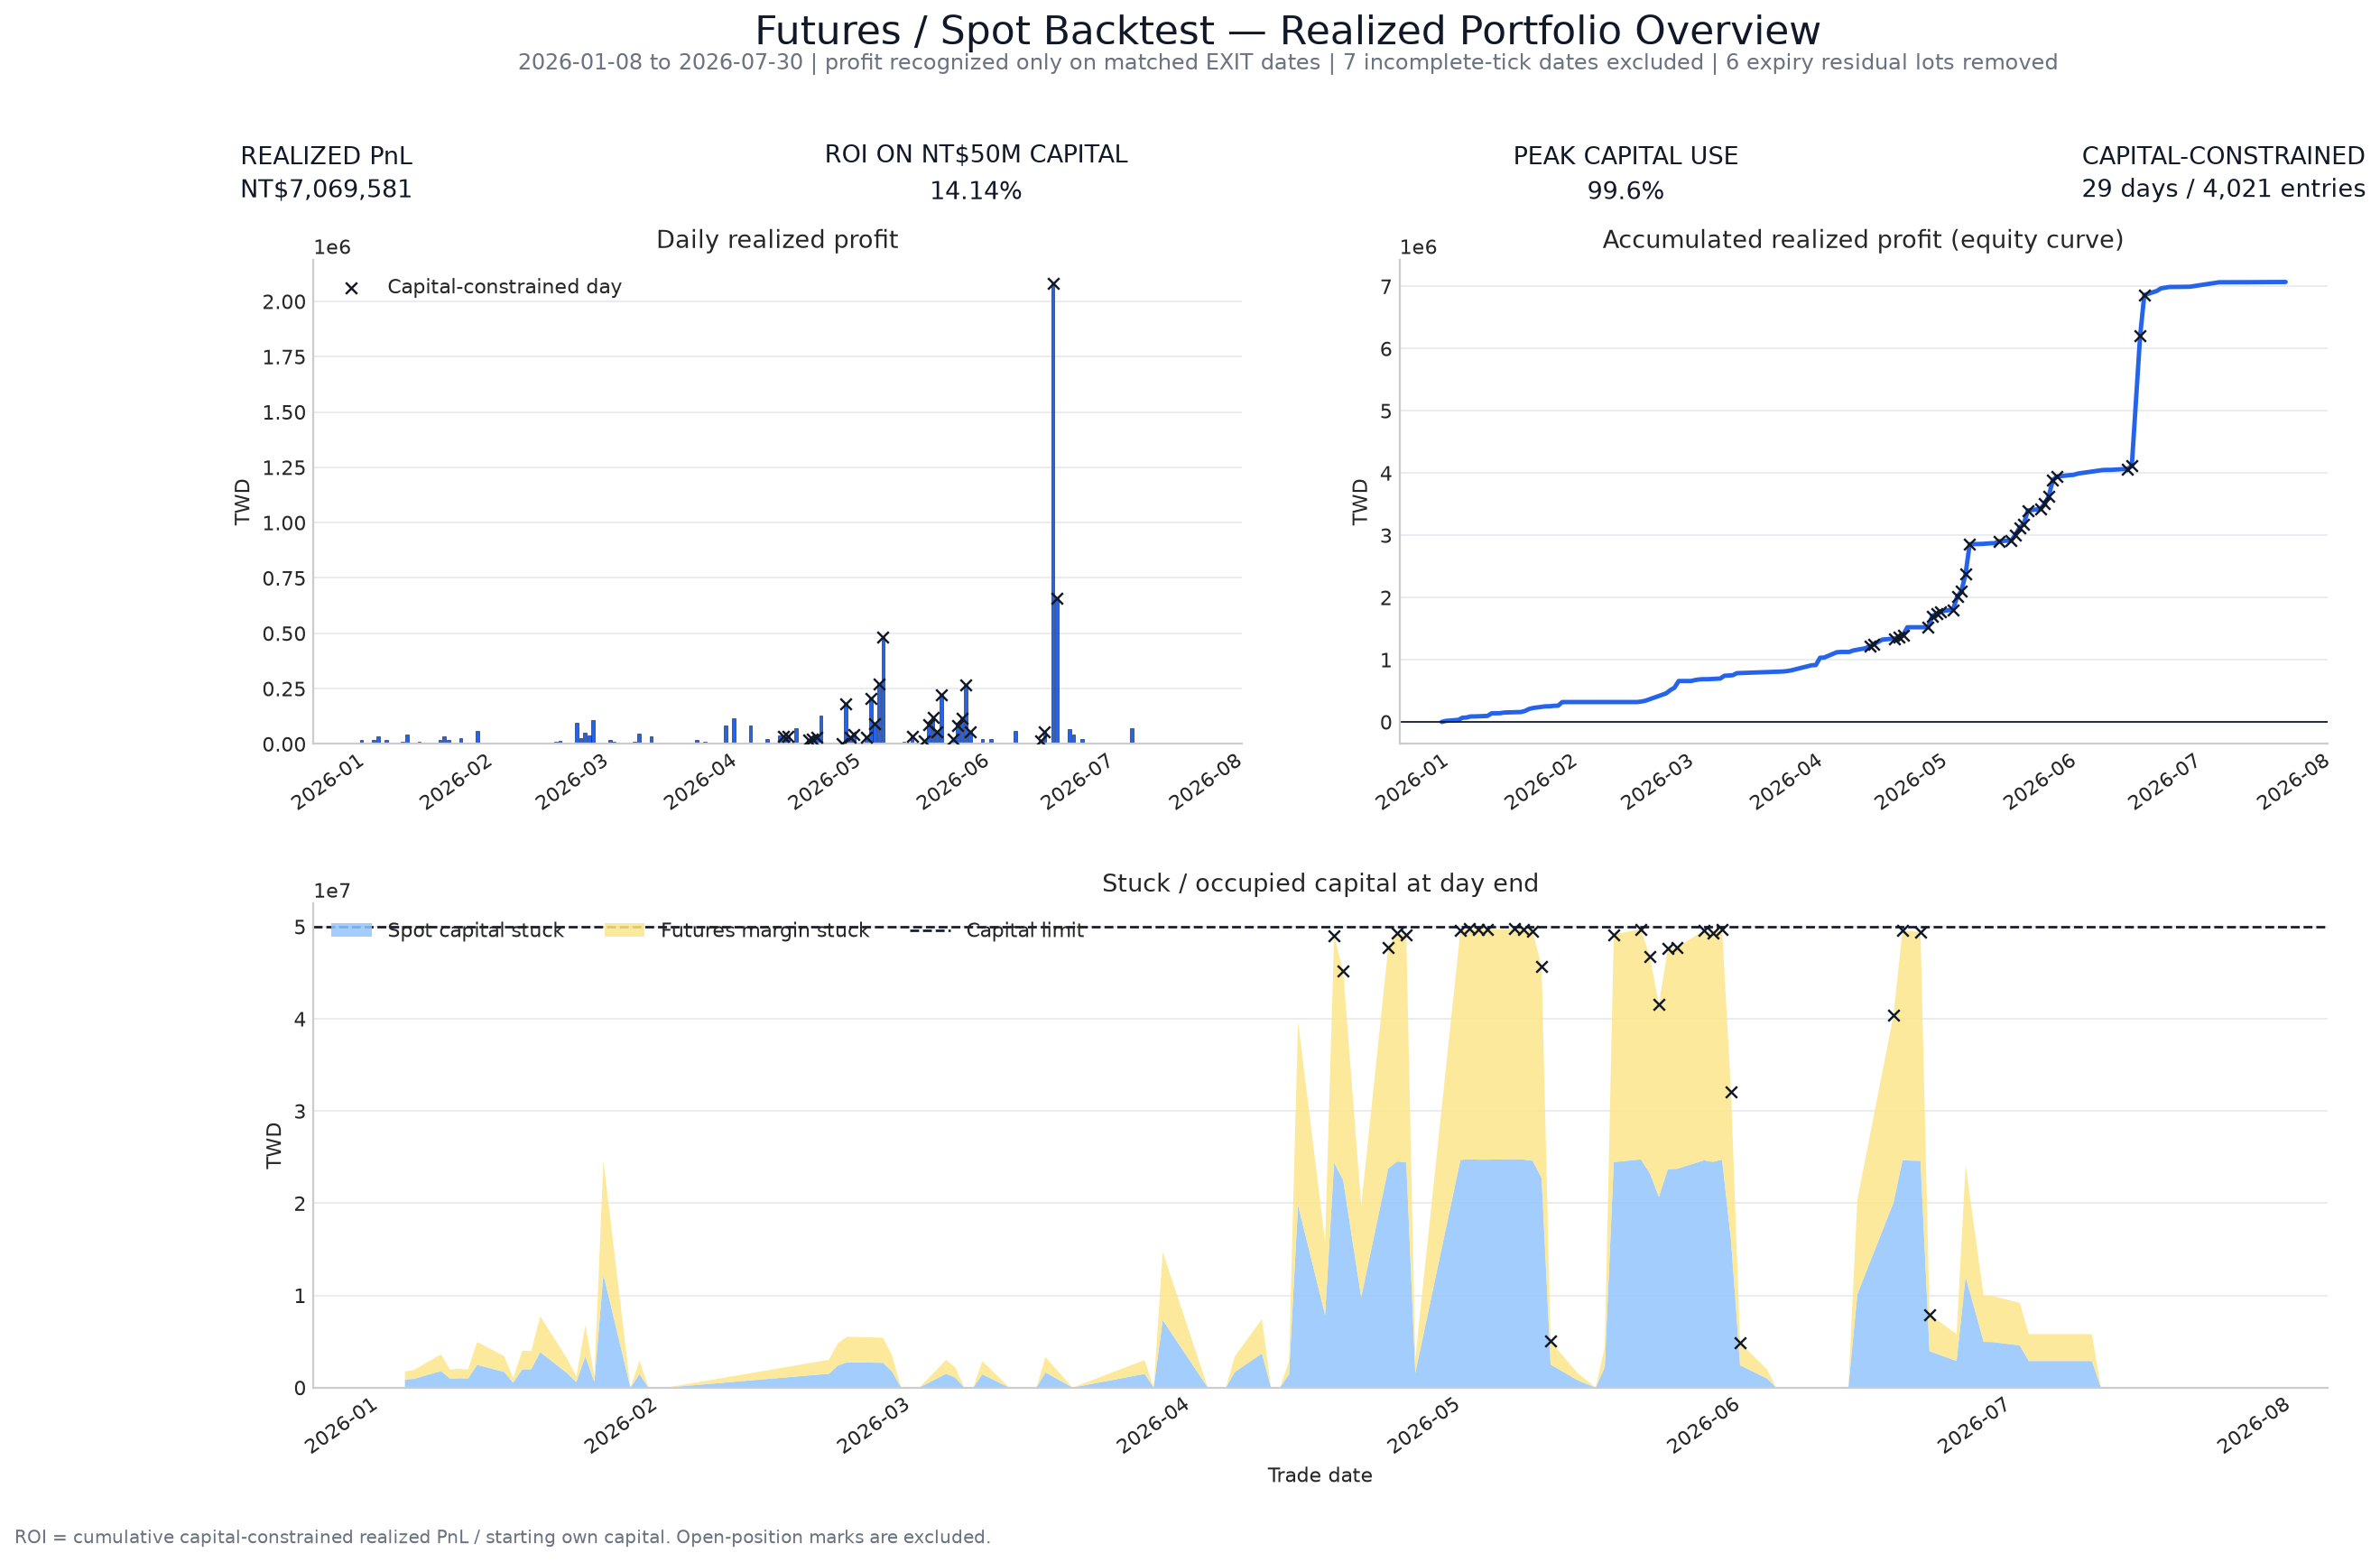

performance_overview: /home/zoufuc/hftbacktest/future_spot/output/hbt_daily_full_market_20260101_20260731_future_order_1ms_response_1ms_feed_0ms_spot_order_1ms_response_35ms_feed_0ms/figures/performance_overview.png


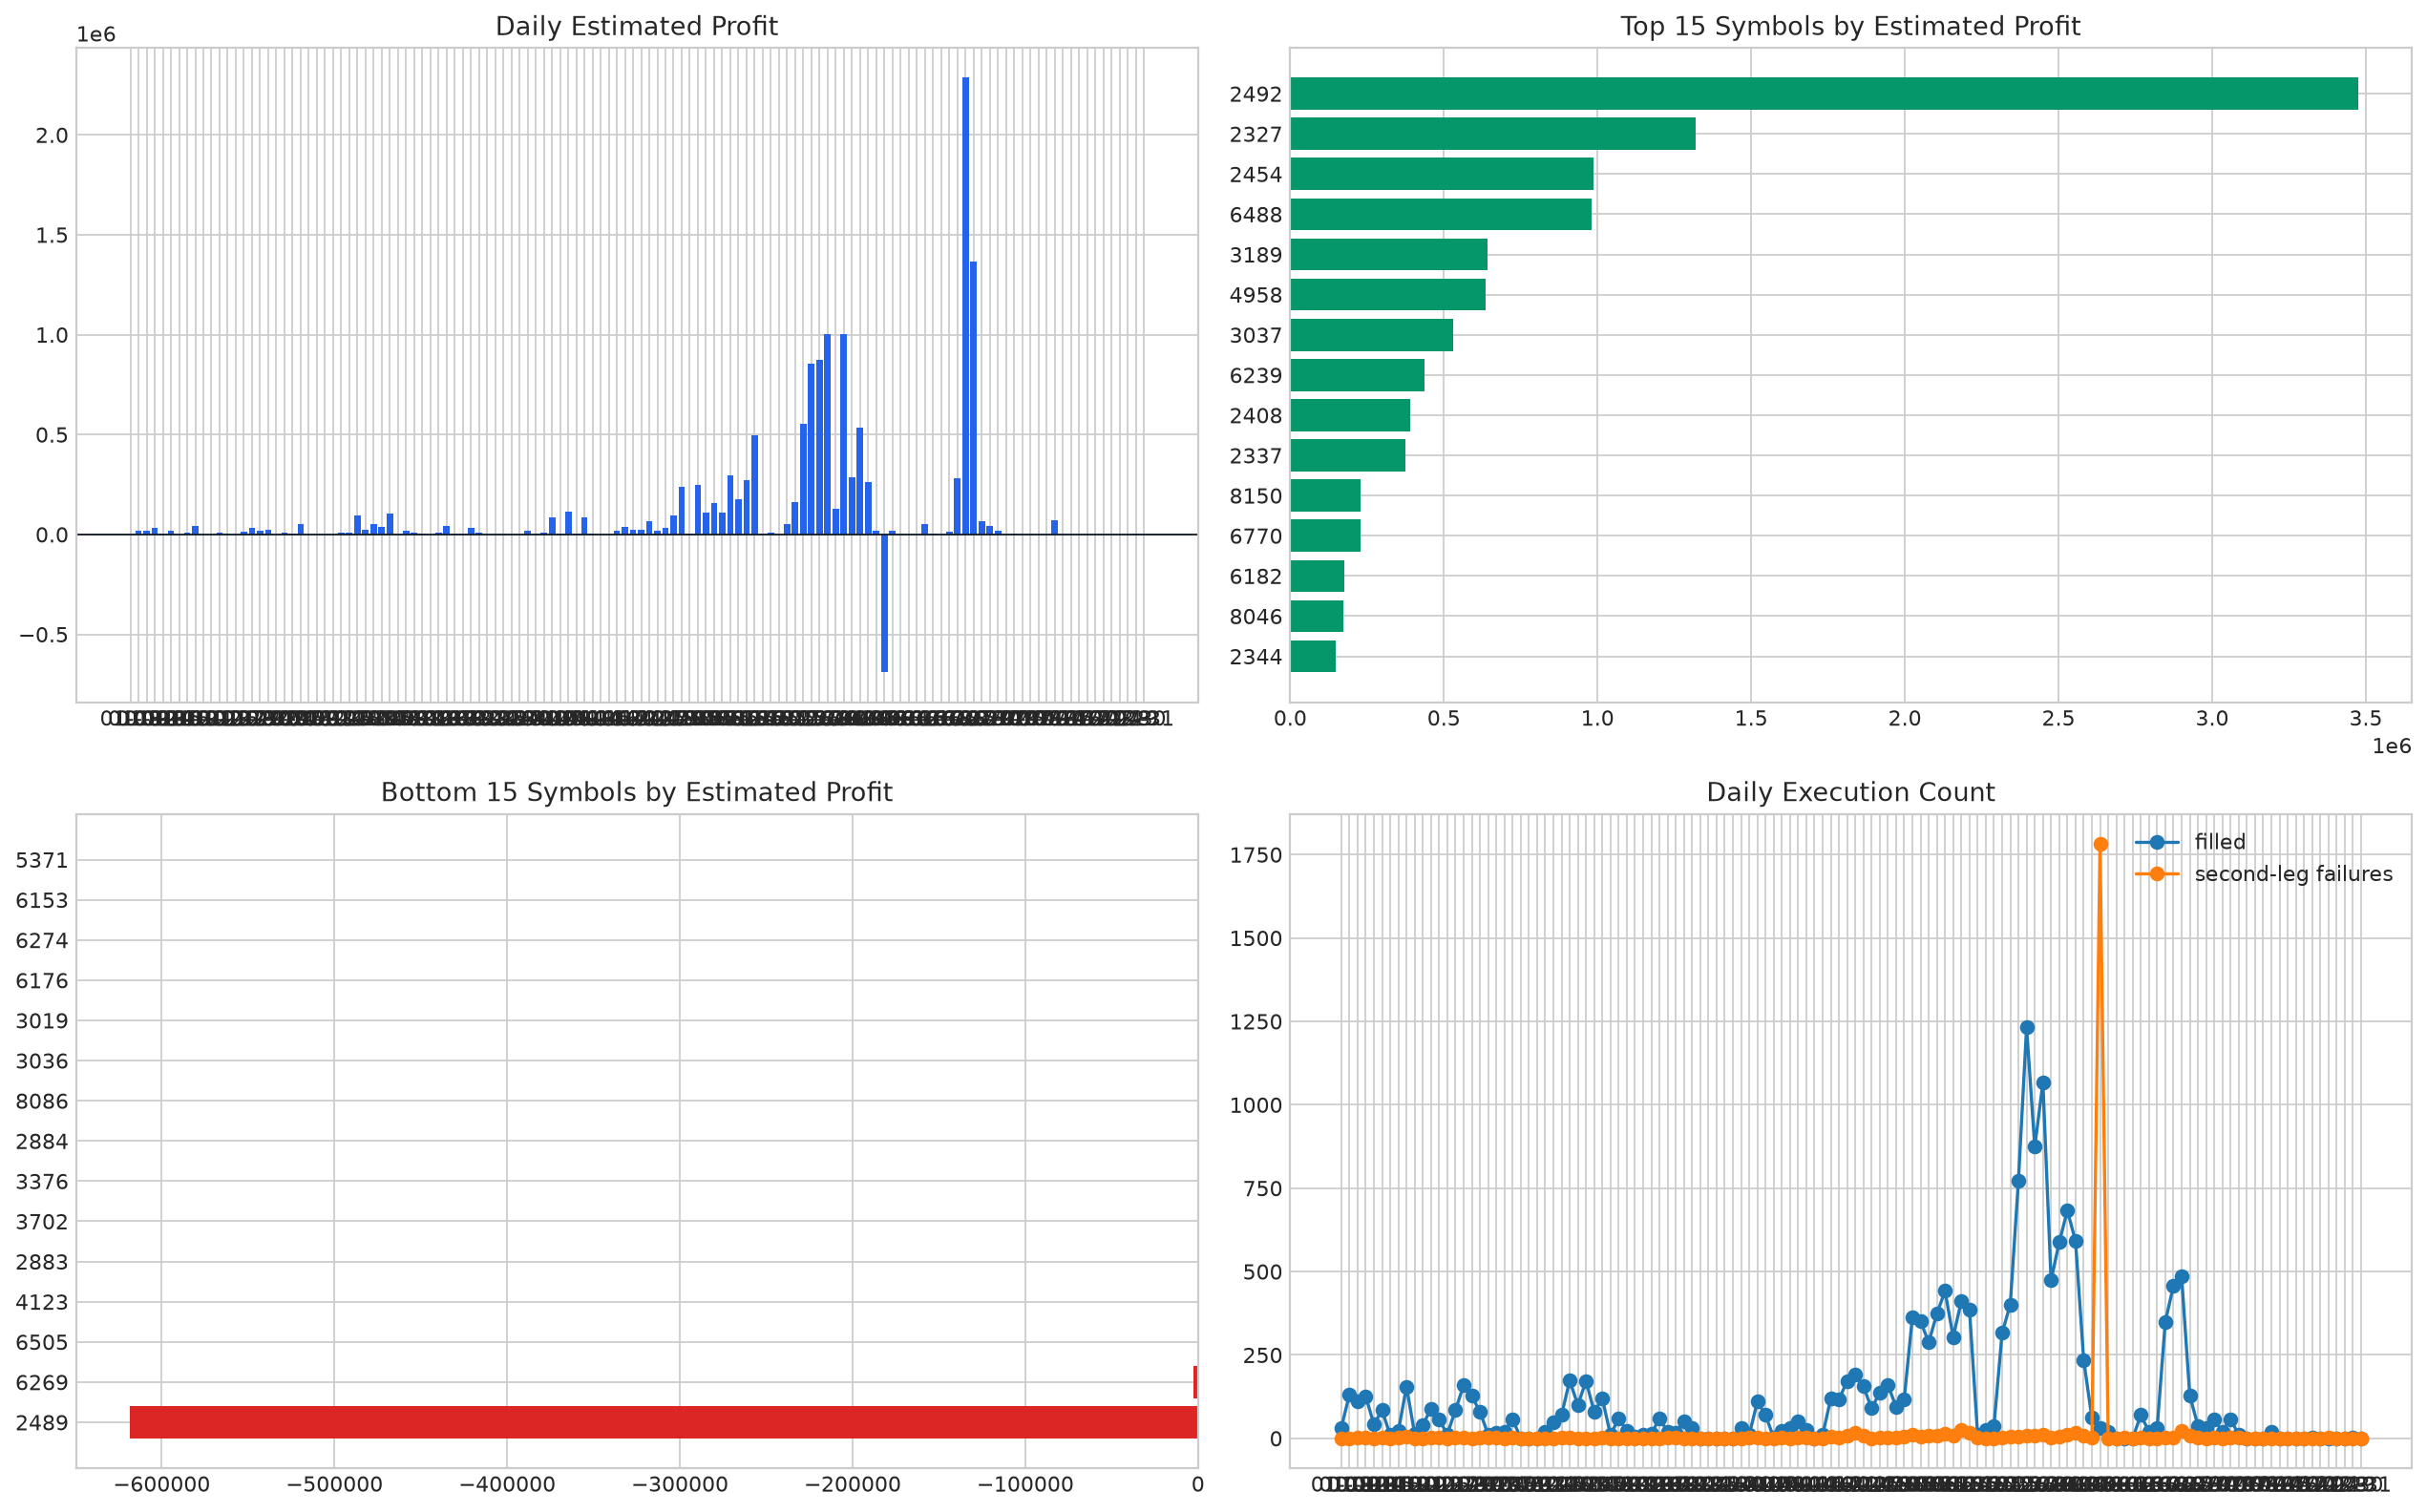

pair_profit_scatter: /home/zoufuc/hftbacktest/future_spot/output/hbt_daily_full_market_20260101_20260731_future_order_1ms_response_1ms_feed_0ms_spot_order_1ms_response_35ms_feed_0ms/figures/pair_profit_scatter.png


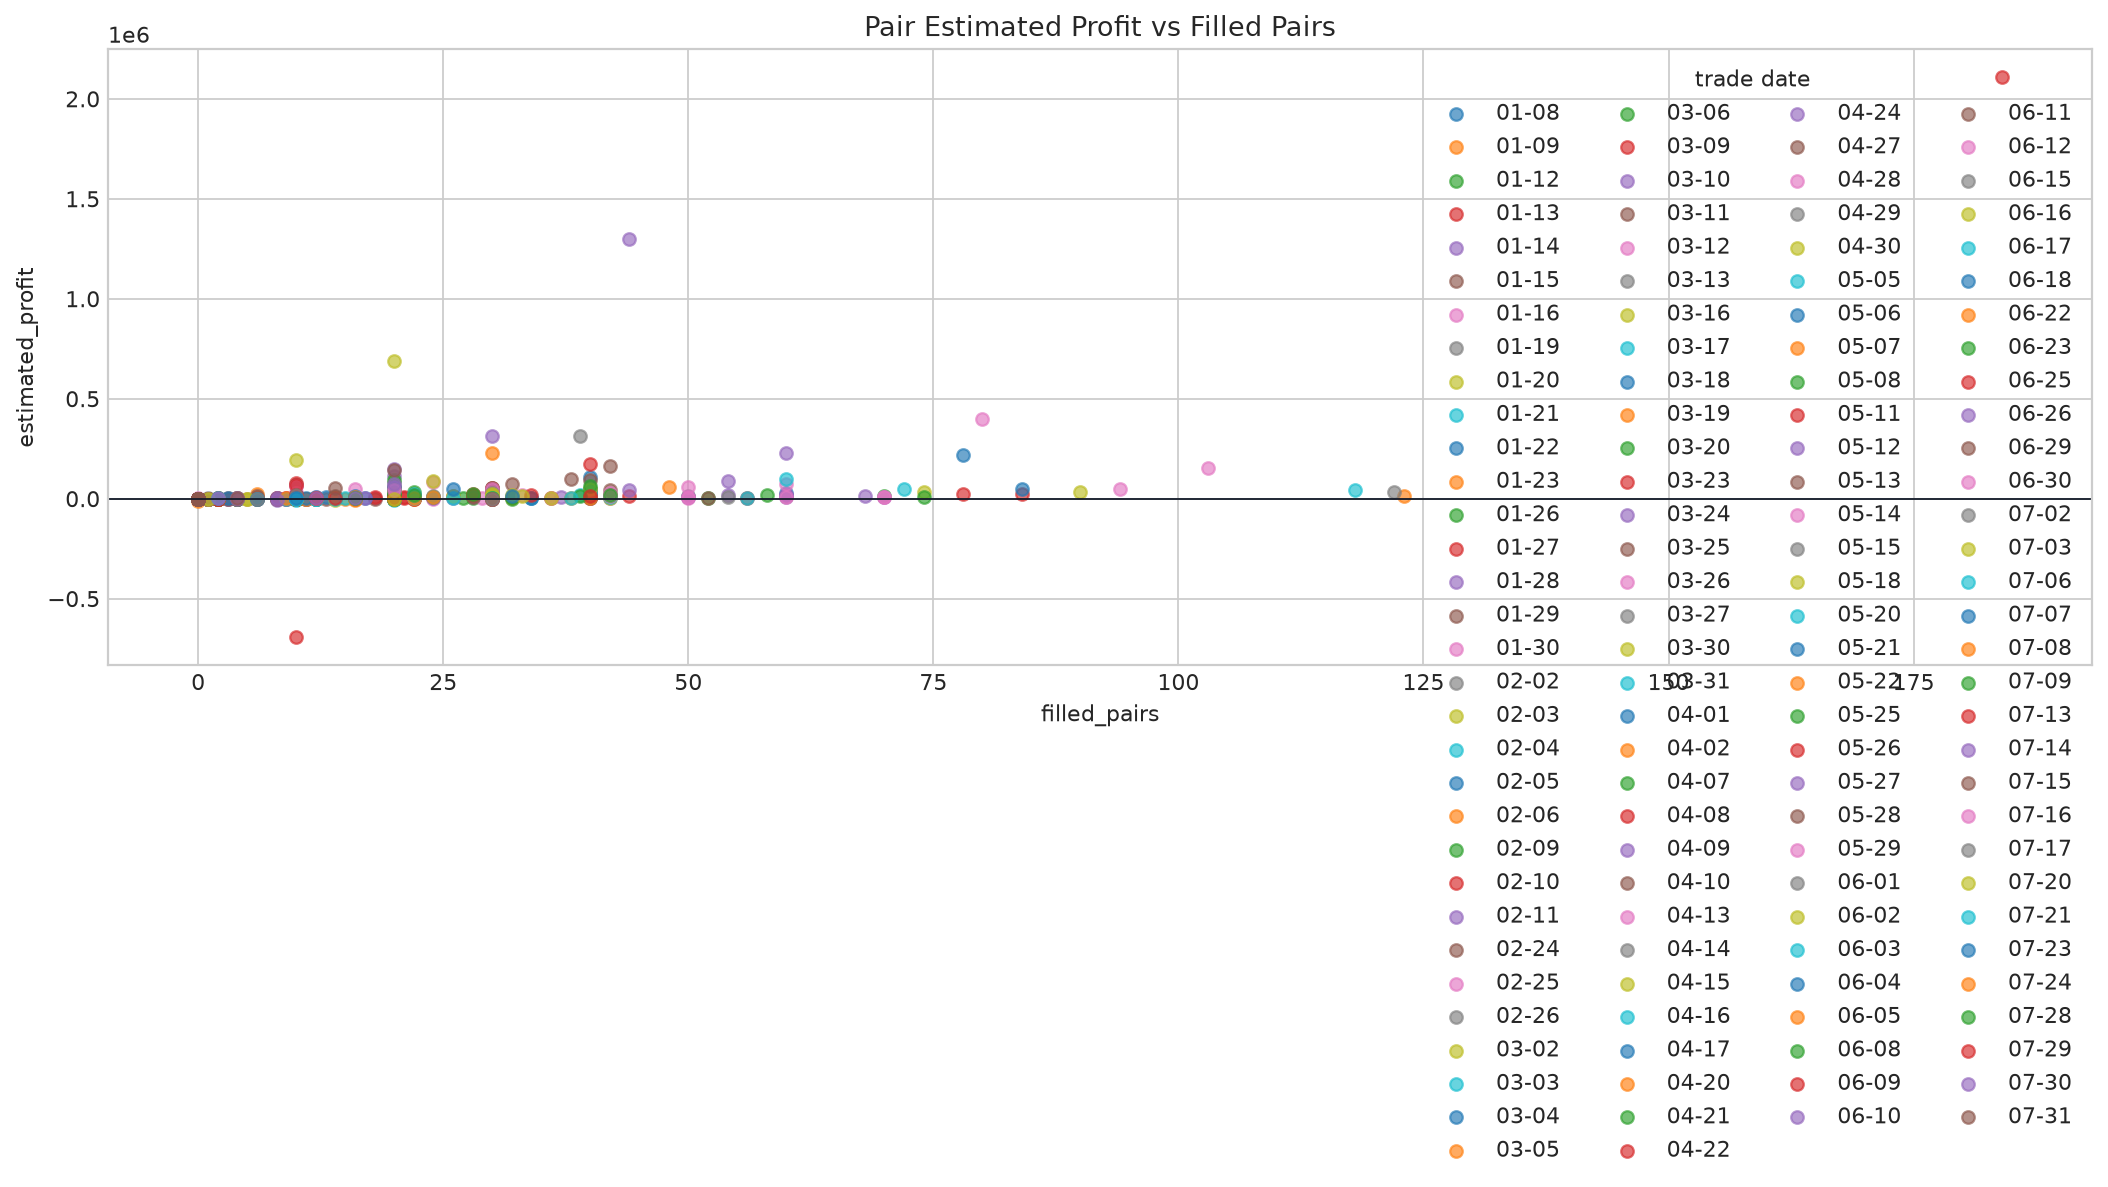

stuck_cash: /home/zoufuc/hftbacktest/future_spot/output/hbt_daily_full_market_20260101_20260731_future_order_1ms_response_1ms_feed_0ms_spot_order_1ms_response_35ms_feed_0ms/figures/stuck_cash.png


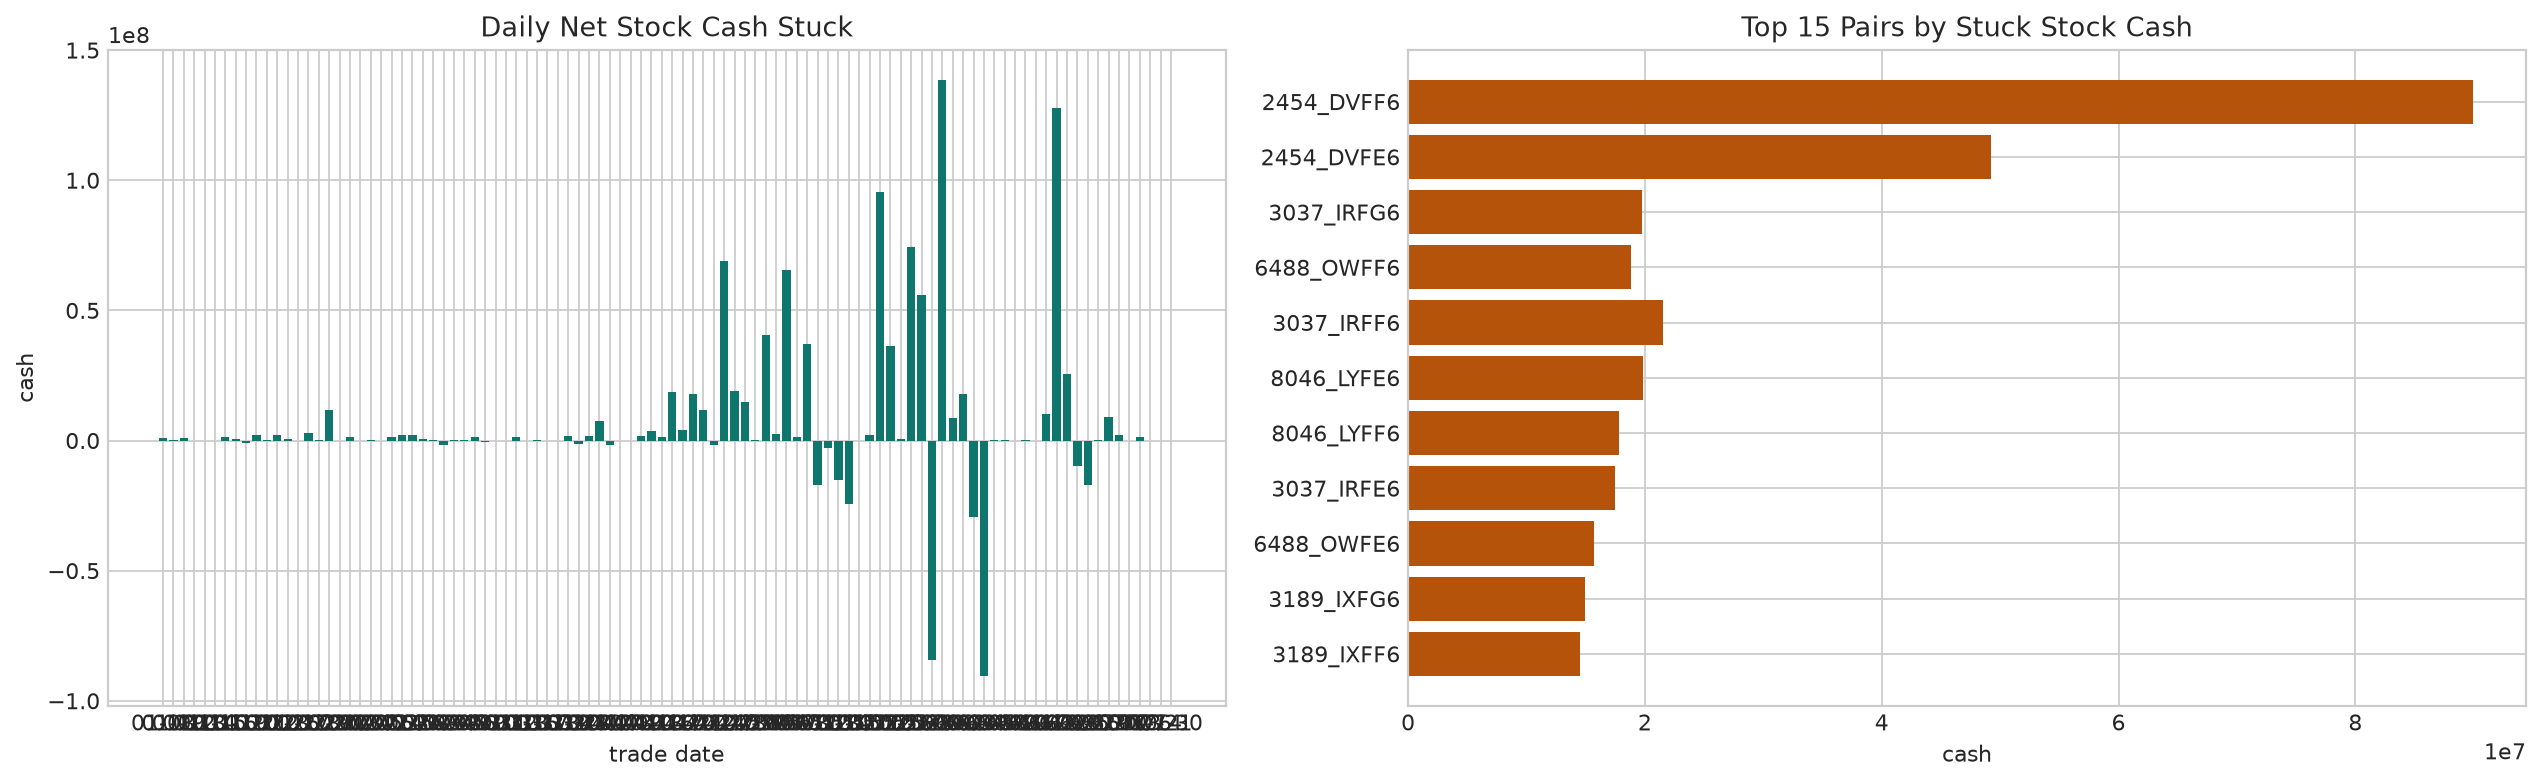

latency_timelines: /home/zoufuc/hftbacktest/future_spot/output/hbt_daily_full_market_20260101_20260731_future_order_1ms_response_1ms_feed_0ms_spot_order_1ms_response_35ms_feed_0ms/figures/latency_timelines.png


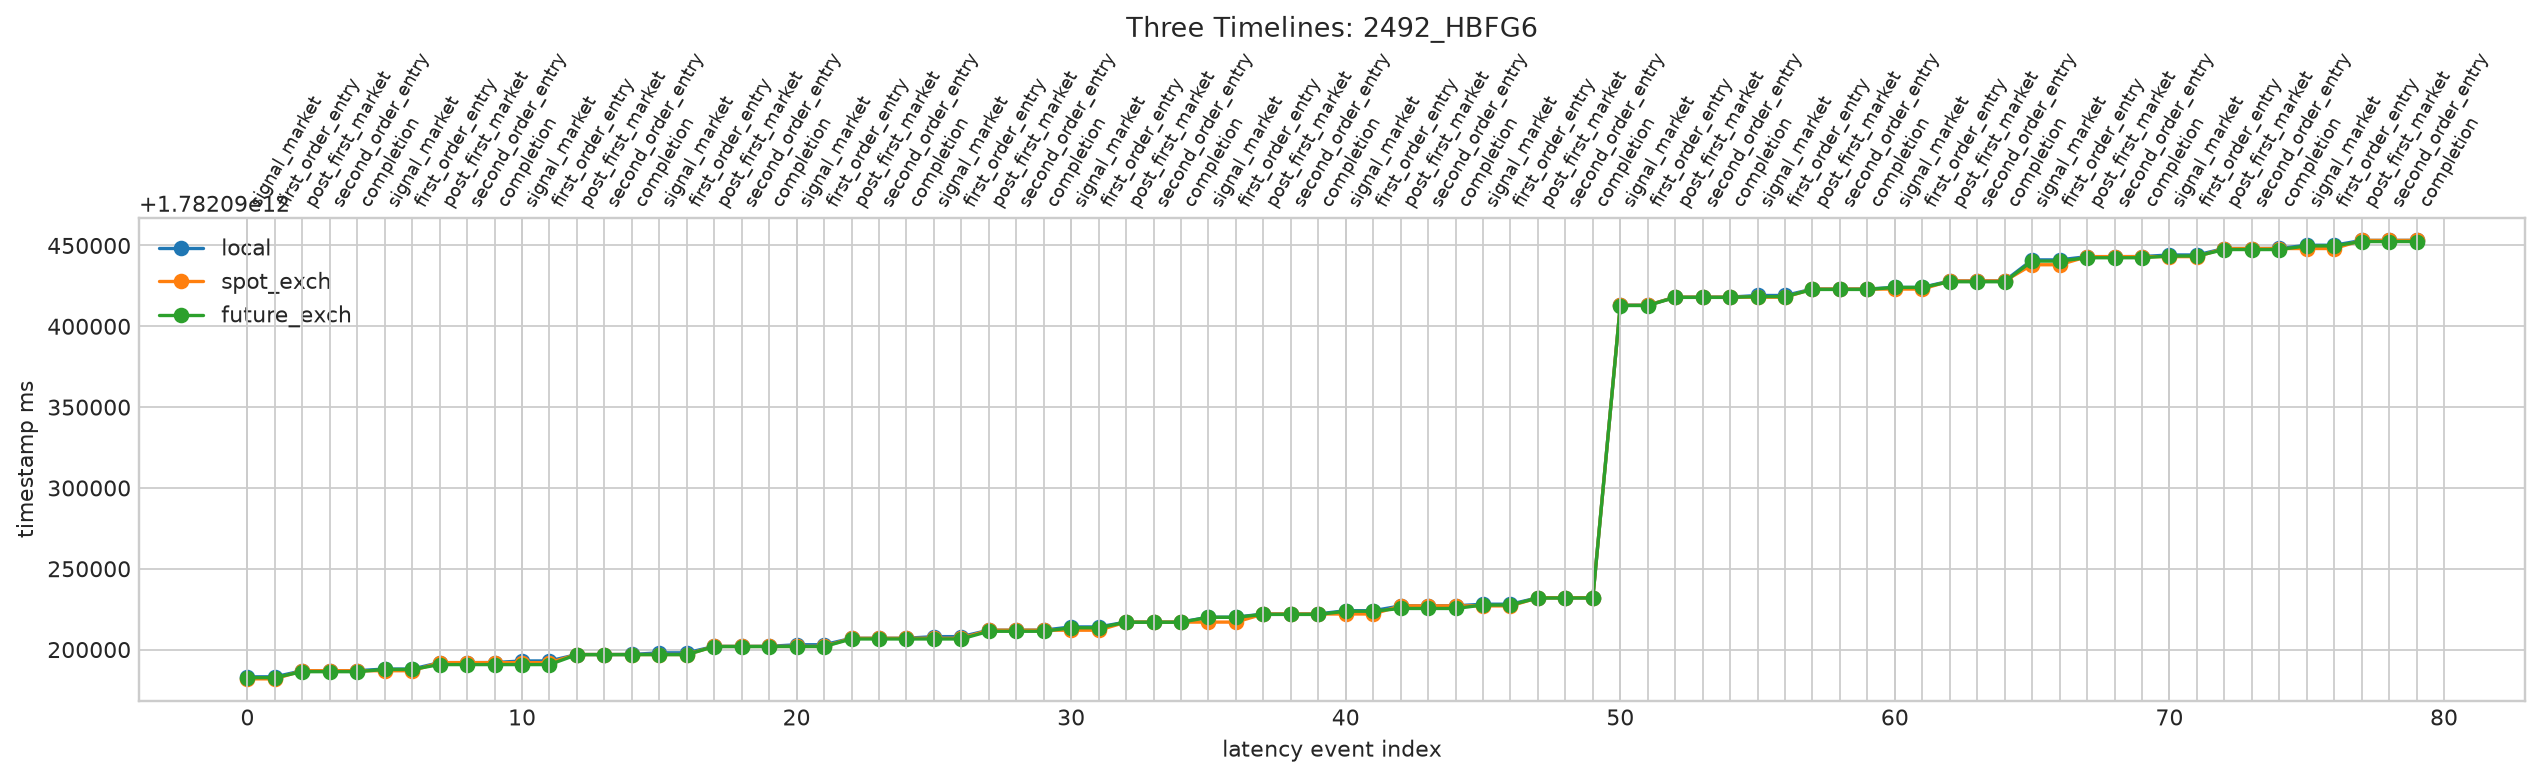

In [5]:
figure_paths = save_report_plots(artifacts, reports, excluded_dates=PLOT_EXCLUDED_DATES)
print(f'Plot excluded dates: {", ".join(PLOT_EXCLUDED_DATES)}')
print(f'Plot exclusion audit: {artifacts.output_dir / "figures" / "plot_exclusions.csv"}')
for name, path in figure_paths.items():
    print(f'{name}: {path}')
    display(Image(filename=str(path)))

## 5. 選擇性逐 pair 檢查

In [6]:
selected_pair = reports.selected_pair
entry_exit = artifacts.frame('entry_exit_all')
latency = artifacts.frame('latency')
if selected_pair is None:
    print('No pair is available for drill-down.')
else:
    if 'pair_name' in entry_exit.columns:
        display(entry_exit.loc[entry_exit['pair_name'].eq(selected_pair)].head(100))
    if 'pair_name' in latency.columns:
        display(latency.loc[latency['pair_name'].eq(selected_pair)].head(120))